# Notebook 06 — Risk Scoring & Explainability
## Machine Learning-based Late Delivery Risk Prediction in Global Supply Chain Operations
**Client:** APL Logistics (KWE Group) | **Platform:** Unified Mentor

### Objective
This notebook generates late delivery probability scores for all orders, assigns risk categories (Low / Medium / High), identifies key risk drivers per order, builds the high-risk order list, and saves all outputs for the Streamlit app.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
OUTPUTS_PATH = '../outputs/'
FIG_PATH = '../reports/eda_figures/'
MODELS_PATH = '../models/'
os.makedirs(OUTPUTS_PATH, exist_ok=True)

print("Imports successful.")

Imports successful.


In [3]:
# Load processed test set
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# Load original cleaned data for display purposes
df_clean = pd.read_csv('../data/cleaned_data.csv')

# Load best model
best_model = joblib.load(MODELS_PATH + 'best_model.pkl')

# Load feature importance
feature_names = X_test.columns.tolist()

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Best model loaded: {type(best_model).__name__}")

X_test shape: (36104, 29)
y_test shape: (36104,)
Best model loaded: XGBClassifier


##  Generate Late Delivery Probability Scores
Using the tuned XGBoost model to generate probability scores for each order in the test set. predict_proba returns probability of class 1 (Late) for each order.

In [4]:
# Generate probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print(f"Probability scores generated for {len(y_prob):,} orders")
print(f"\nProbability Distribution:")
print(f"  Min:    {y_prob.min():.4f}")
print(f"  Max:    {y_prob.max():.4f}")
print(f"  Mean:   {y_prob.mean():.4f}")
print(f"  Median: {np.median(y_prob):.4f}")

Probability scores generated for 36,104 orders

Probability Distribution:
  Min:    0.0000
  Max:    1.0000
  Mean:   0.5474
  Median: 0.8703


##  Assign Risk Categories
Each order receives a risk category based on its late delivery probability:
- **Low Risk:** probability < 0.4
- **Medium Risk:** 0.4 ≤ probability < 0.7
- **High Risk:** probability ≥ 0.7

In [5]:
def assign_risk_category(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_categories = pd.Series(y_prob).apply(assign_risk_category)

# Summary
risk_summary = risk_categories.value_counts()
risk_pct = risk_categories.value_counts(normalize=True) * 100

risk_table = pd.DataFrame({
    'Count': risk_summary,
    'Percentage': risk_pct.round(2)
})

print("Risk Category Distribution:")
print("=" * 40)
display(risk_table)

Risk Category Distribution:


,Count,Percentage
High Risk,19977,55.33
Low Risk,15538,43.04
Medium Risk,589,1.63


##  Build Scored Dataset
Combining test set results with probability scores, risk categories, and actual labels into one comprehensive scored dataset.

In [6]:
scored_df = X_test.copy()
scored_df['Actual_Late_Delivery_Risk'] = y_test.values
scored_df['Late_Delivery_Probability'] = y_prob.round(4)
scored_df['Predicted_Risk'] = y_pred
scored_df['Risk_Category'] = risk_categories.values

# Reorder columns for clarity
cols_order = ['Late_Delivery_Probability', 'Risk_Category',
              'Actual_Late_Delivery_Risk', 'Predicted_Risk'] + feature_names
scored_df = scored_df[cols_order]

print(f"Scored dataset shape: {scored_df.shape}")
display(scored_df.head(10))

Scored dataset shape: (36104, 33)


,Late_Delivery_Probability,Risk_Category,Actual_Late_Delivery_Risk,Predicted_Risk,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Order Region,Order State,Product Name,Shipping Mode,shipping_delay_gap,shipping_pressure_index,is_express,high_discount_flag,order_complexity_score,region_congestion_score
0,1.0,High Risk,1,1,1,-0.922442,-1.406202,0.718374,0.724670,9,59,0,0,31,3,1,3198,53,0.429132,-0.025111,1.139279,0.512929,-0.775598,22,570,21,0,0.292053,-0.900751,1,0,0.728551,1.003834
1,0.0,Low Risk,0,0,0,-0.306230,0.777012,-0.002248,-0.075976,46,522,0,0,42,3,1,1173,120,0.245153,0.400824,0.421996,0.020004,-0.775598,10,324,70,3,-1.049689,1.280773,0,1,-0.028612,-0.774027
2,1.0,High Risk,1,1,2,1.542404,0.777012,1.512358,1.742263,18,66,1,2,36,3,3,570,8,-0.582751,-1.160939,1.856633,0.727244,-0.775598,11,979,24,3,0.962924,1.280773,0,0,1.485790,-0.797300
3,0.0,Low Risk,0,0,3,0.309981,0.777012,0.197203,-0.301098,47,220,0,1,22,6,4,2052,48,-0.812725,-1.160939,-0.653964,0.362908,0.598714,18,983,59,3,-0.378818,-0.173577,0,0,-0.407156,0.404560
4,0.0,Low Risk,0,0,1,-0.922442,-0.678464,1.567761,1.775627,18,210,0,1,5,3,4,3442,48,-0.766730,-1.302918,1.856633,0.748676,-0.775598,6,278,24,2,-0.378818,-0.173577,0,0,1.485790,0.819588
5,1.0,High Risk,1,1,2,0.309981,-0.678464,0.467054,0.049221,47,66,1,1,36,6,0,847,147,-0.444767,-0.593025,-0.653964,0.555792,1.285870,5,276,59,2,0.962924,-1.046186,0,0,-0.028537,1.093405
6,1.0,High Risk,1,1,2,0.926193,-0.678464,0.146385,-0.638154,34,257,0,2,5,0,2,2849,124,0.125567,1.110717,-0.080152,0.491497,-0.775598,1,890,56,2,1.633795,-0.173577,0,1,-0.558680,-1.726218
7,0.0,Low Risk,0,0,3,-0.922442,0.777012,0.112570,-0.627311,34,66,1,0,36,0,1,477,53,0.065774,0.968738,-0.080152,0.405771,-0.775598,22,160,56,3,-1.720559,1.280773,0,1,-0.558680,1.003834
8,1.0,High Risk,1,1,2,1.542404,0.777012,-0.056218,-0.338632,47,66,1,1,36,6,2,3106,20,-0.605749,-0.735004,-0.653964,-0.022859,0.598714,12,953,59,3,0.962924,-0.173577,0,0,-0.407156,-0.513379
9,1.0,High Risk,1,1,2,-0.922442,-1.406202,0.116486,-0.616468,34,144,0,2,40,0,1,2748,53,0.005981,0.826760,-0.080152,0.405771,-0.775598,22,461,56,0,0.292053,-0.900751,1,1,-0.558680,1.003834


##  Feature Importance — Key Risk Drivers
Identifying the top features that drive late delivery risk across all orders. This fulfills the 'Key Risk Drivers' KPI requirement.

In [7]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

risk_drivers_table = pd.DataFrame({
    'Feature': feature_importance.index,
    'Importance Score': feature_importance.values.round(4),
    'Rank': range(1, len(feature_importance) + 1)
}).reset_index(drop=True)

print("KEY RISK DRIVERS — Global Feature Importance")
print("=" * 50)
display(risk_drivers_table.head(15))

KEY RISK DRIVERS — Global Feature Importance


,Feature,Importance Score,Rank
0,shipping_delay_gap,0.7938,1
1,Type,0.1671,2
2,Days for shipment (scheduled),0.0023,3
3,Customer Country,0.0020,4
4,Order Country,0.0019,5
5,Market,0.0019,6
6,region_congestion_score,0.0019,7
7,Order State,0.0019,8
8,Customer City,0.0019,9
9,Order City,0.0018,10


##  Per-Order Risk Explanation
For each order, identifying which features contributed most to its risk score. This fulfills the 'Explanation of why an order is high risk' requirement.

In [8]:
def explain_order_risk(order_index, top_n=5):
    """
    Explains why a specific order has its risk score.
    Returns top N features driving the risk for that order.
    """
    order = X_test.iloc[order_index]
    prob = y_prob[order_index]
    category = assign_risk_category(prob)
    
    # Feature importance as risk driver weights
    importance_weights = best_model.feature_importances_
    
    # Weight each feature value by its importance
    weighted_features = pd.Series(
        np.abs(order.values) * importance_weights,
        index=feature_names
    ).sort_values(ascending=False)
    
    top_drivers = weighted_features.head(top_n)
    
    print(f"Order Index: {order_index}")
    print(f"Late Delivery Probability: {prob:.2%}")
    print(f"Risk Category: {category}")
    print(f"\nTop {top_n} Risk Drivers:")
    for feature, score in top_drivers.items():
        print(f"  {feature}: {order[feature]:.4f} (driver score: {score:.4f})")
    
    return top_drivers

# Example — show explanation for a high risk order
high_risk_indices = np.where(risk_categories.values == 'High Risk')[0]
if len(high_risk_indices) > 0:
    print("EXAMPLE — HIGH RISK ORDER EXPLANATION")
    print("=" * 50)
    explain_order_risk(high_risk_indices[0])

EXAMPLE — HIGH RISK ORDER EXPLANATION
Order Index: 0
Late Delivery Probability: 100.00%
Risk Category: High Risk

Top 5 Risk Drivers:
  Order City: 3198.0000 (driver score: 5.8474)
  Order State: 570.0000 (driver score: 1.0630)
  shipping_delay_gap: 0.2921 (driver score: 0.2318)
  Type: 1.0000 (driver score: 0.1671)
  Customer City: 59.0000 (driver score: 0.1094)


##  High Risk Order List
Filtering all High Risk orders sorted by probability descending. This is the operational action queue — orders that need immediate attention.

In [9]:
high_risk_df = scored_df[scored_df['Risk_Category'] == 'High Risk'].copy()
high_risk_df = high_risk_df.sort_values('Late_Delivery_Probability', ascending=False)
high_risk_df = high_risk_df.reset_index(drop=True)

print(f"Total High Risk Orders: {len(high_risk_df):,}")
print(f"Percentage of test set: {len(high_risk_df)/len(scored_df)*100:.2f}%")
print(f"\nTop 10 Highest Risk Orders:")
display(high_risk_df[['Late_Delivery_Probability', 'Risk_Category',
                        'Actual_Late_Delivery_Risk']].head(10))

Total High Risk Orders: 19,977
Percentage of test set: 55.33%

Top 10 Highest Risk Orders:


,Late_Delivery_Probability,Risk_Category,Actual_Late_Delivery_Risk
0,1.0,High Risk,1
1,1.0,High Risk,1
2,1.0,High Risk,1
3,1.0,High Risk,1
4,1.0,High Risk,1
5,1.0,High Risk,1
6,1.0,High Risk,1
7,1.0,High Risk,1
8,1.0,High Risk,1
9,1.0,High Risk,1


##  Risk Distribution Visualization

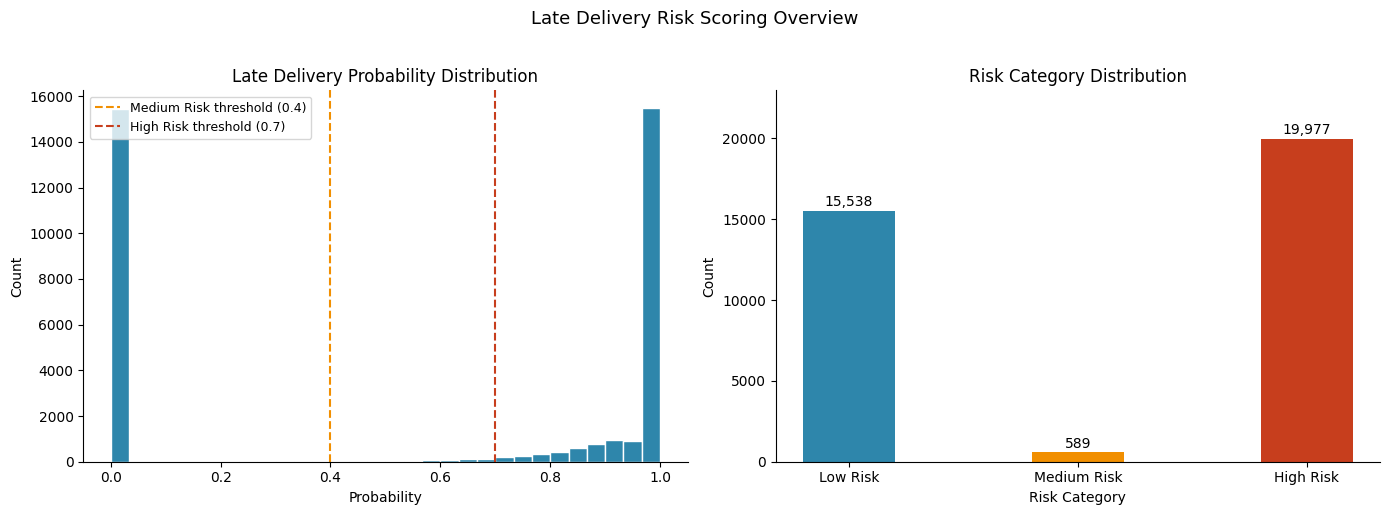

Saved: 14_risk_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Probability distribution
axes[0].hist(y_prob, bins=30, color=COLORS[0], edgecolor='white')
axes[0].axvline(0.4, color=COLORS[2], linestyle='--',
                linewidth=1.5, label='Medium Risk threshold (0.4)')
axes[0].axvline(0.7, color=COLORS[3], linestyle='--',
                linewidth=1.5, label='High Risk threshold (0.7)')
axes[0].set_title('Late Delivery Probability Distribution', fontsize=12)
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Plot 2 — Risk category distribution
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
risk_counts = [risk_summary.get(cat, 0) for cat in risk_order]
bar_colors = [COLORS[0], COLORS[2], COLORS[3]]

bars = axes[1].bar(risk_order, risk_counts, color=bar_colors, width=0.4)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 100,
                 f'{bar.get_height():,}',
                 ha='center', va='bottom', fontsize=10)

axes[1].set_title('Risk Category Distribution', fontsize=12)
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(risk_counts) * 1.15)
sns.despine()

plt.suptitle('Late Delivery Risk Scoring Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + '14_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 14_risk_distribution.png")

##  Save Outputs

In [11]:
# Save full scored dataset
scored_df.to_csv(OUTPUTS_PATH + 'scored_dataset.csv', index=False)
print(f"Saved: outputs/scored_dataset.csv ({len(scored_df):,} rows)")

# Save high risk orders
high_risk_df.to_csv(OUTPUTS_PATH + 'high_risk_orders.csv', index=False)
print(f"Saved: outputs/high_risk_orders.csv ({len(high_risk_df):,} rows)")

# Save risk drivers table
risk_drivers_table.to_csv(OUTPUTS_PATH + 'risk_drivers.csv', index=False)
print(f"Saved: outputs/risk_drivers.csv")

# Save risk category thresholds for app
risk_thresholds = {
    'low_risk_max': 0.4,
    'medium_risk_max': 0.7,
    'high_risk_min': 0.7
}
joblib.dump(risk_thresholds, MODELS_PATH + 'risk_thresholds.pkl')
print(f"Saved: models/risk_thresholds.pkl")

Saved: outputs/scored_dataset.csv (36,104 rows)
Saved: outputs/high_risk_orders.csv (19,977 rows)
Saved: outputs/risk_drivers.csv
Saved: models/risk_thresholds.pkl


##  Risk Scoring Summary

In [12]:
print("=" * 60)
print("RISK SCORING SUMMARY")
print("=" * 60)
print(f"\nTotal orders scored:        {len(scored_df):,}")
print(f"\nRisk Category Breakdown:")
for cat in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = risk_summary.get(cat, 0)
    pct = risk_pct.get(cat, 0)
    print(f"  {cat}: {count:,} orders ({pct:.2f}%)")

print(f"\nTop 5 Global Risk Drivers:")
for i, (feature, score) in enumerate(feature_importance.head(5).items()):
    print(f"  {i+1}. {feature}: {score:.4f}")

print(f"\nProbability Thresholds:")
print(f"  Low Risk:    < 0.4")
print(f"  Medium Risk: 0.4 — 0.7")
print(f"  High Risk:   ≥ 0.7")

print(f"\nSaved to outputs/:")
print(f"  scored_dataset.csv")
print(f"  high_risk_orders.csv")
print(f"  risk_drivers.csv")
print(f"\nSaved to models/:")
print(f"  risk_thresholds.pkl")

RISK SCORING SUMMARY

Total orders scored:        36,104

Risk Category Breakdown:
  High Risk: 19,977 orders (55.33%)
  Medium Risk: 589 orders (1.63%)
  Low Risk: 15,538 orders (43.04%)

Top 5 Global Risk Drivers:
  1. shipping_delay_gap: 0.7938
  2. Type: 0.1671
  3. Days for shipment (scheduled): 0.0023
  4. Customer Country: 0.0020
  5. Order Country: 0.0019

Probability Thresholds:
  Low Risk:    < 0.4
  Medium Risk: 0.4 — 0.7
  High Risk:   ≥ 0.7

Saved to outputs/:
  scored_dataset.csv
  high_risk_orders.csv
  risk_drivers.csv

Saved to models/:
  risk_thresholds.pkl
